# Análise Exploratória

Aqui iniciamos nossa análise exploratória da base de dados. Como o arquivo original possuia 6Gb de tamanho e com a limpeza de dados chegamos a ter um volume de 2Gb.

## 1. Importação dos dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

def quebrar_texto(texto, largura=15):
    return "\n".join(textwrap.wrap(texto, largura))

def plot_media(df, coluna, group_col, titulo):
    df_plot = (
        df
        .groupby(group_col)[coluna]
        .mean()
        .sort_values(ascending=False)
    )
    
    plt.figure(figsize=(6, 3))
    ax = df_plot.plot(kind="bar")
    
    plt.title(titulo)
    plt.xlabel(group_col)
    plt.ylabel(f"Média de {coluna}")
    plt.xticks(rotation=45)
    
    # rótulos
    for i, v in enumerate(df_plot):
        ax.text(i, v, f"{v:.0f}", ha="center", va="bottom")
    
    plt.tight_layout()
    plt.show()

df = pd.read_csv(
    r"C:\Users\leona\OneDrive\Documentos\MBA Eng Dados\Projeto Final de curso\base de dados\base_final_202605161057.csv",
    sep=";",
    encoding="latin-1"
)

C:\Users\leona\AppData\Local\Temp\ipykernel_16904\745034800.py:33: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## 2. Iniciando análise do dataframe

### 2.1 Analisando características do dataframe e ajuste de formatos

- Target: Status

Esse é nome da coluna que diz se a empresa faliu ou não. Elas se baseia na coluna "Situação Cadastral", se 8 então faliu senão ativo.

In [119]:
mapeamento = {2: "ATIVO", 8: "FALIU"}
df["status"] = df["situacao_cadastral"].map(mapeamento)

- Definindo o porte das empresas

Se o valor de porte_empresas for 5 então grande porte, se 1 micro empresa e se for 3 empresa de pequeno porte.

In [120]:
mapeamento = {1: "Micro", 3: "Pequeno", 5: "Grande"}
df["porte_da_empresa"] = df["porte_empresa"].map(mapeamento)

- Informações Gerais do Dataframe

In [121]:
colunas = df.columns.tolist()

print(f"Tamanho do DataFrame amostrado (linhas, colunas): {df.shape}\n")
print("Colunas:")

for i in range(0, len(colunas), 5):
    linha = " | ".join(colunas[i:i + 5])
    print(linha)

Tamanho do DataFrame amostrado (linhas, colunas): (9137658, 38)

Colunas:
cnpj_basico | cnpj_ordem | cnpj_dv | identificador_mf | nome_fantasia
situacao_cadastral | data_situacao_cadastral | motivo_situacao_cad | pais | data_inicio_atividade
cnae_fiscal_principal | cnae_fiscal_secundaria | uf | municipio | situacao_especial
data_situacao_especial | empresa_mais_5_anos | tempo_vida | razao_social | natureza_juridica
qualif_responsavel | capital_social | porte_empresa | ente_federativo_resp | identificador_socio
qualif_socio | data_entrada_sociedade | pais_socio | qualif_representante | faixa_etaria
opcao_simples | data_opcao_simples | data_exclusao_simples | opcao_mei | data_opcao_mei
data_exclusao_mei | status | porte_da_empresa


In [122]:
print(display(df.head(3)))

,cnpj_basico,cnpj_ordem,cnpj_dv,identificador_mf,nome_fantasia,situacao_cadastral,data_situacao_cadastral,motivo_situacao_cad,pais,data_inicio_atividade,...,qualif_representante,faixa_etaria,opcao_simples,data_opcao_simples,data_exclusao_simples,opcao_mei,data_opcao_mei,data_exclusao_mei,status,porte_da_empresa
0,1143109,1,40,1,NaN,2,2003-12-20,0,,1996-04-16,...,0,5,N,2022-01-01,2022-12-31,N,NaN,NaN,ATIVO,Pequeno
1,21104946,1,78,1,G&B EMBALAGENS,8,2015-11-13,1,,2014-09-24,...,0,6,N,2014-09-24,2015-11-13,N,NaN,NaN,FALIU,Pequeno
2,21104946,1,78,1,G&B EMBALAGENS,8,2015-11-13,1,,2014-09-24,...,0,7,N,2014-09-24,2015-11-13,N,NaN,NaN,FALIU,Pequeno


None


- Informações dos tipos de cada coluna, no caso temos muitas colunas classificadas como tipo "Object", por isso será necessário corrigir os tipos para carregar na IA corretamente.

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9137658 entries, 0 to 9137657
Data columns (total 38 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   cnpj_basico              int64  
 1   cnpj_ordem               int64  
 2   cnpj_dv                  int64  
 3   identificador_mf         int64  
 4   nome_fantasia            object 
 5   situacao_cadastral       int64  
 6   data_situacao_cadastral  object 
 7   motivo_situacao_cad      int64  
 8   pais                     object 
 9   data_inicio_atividade    object 
 10  cnae_fiscal_principal    int64  
 11  cnae_fiscal_secundaria   object 
 12  uf                       object 
 13  municipio                int64  
 14  situacao_especial        object 
 15  data_situacao_especial   object 
 16  empresa_mais_5_anos      bool   
 17  tempo_vida               float64
 18  razao_social             object 
 19  natureza_juridica        int64  
 20  qualif_responsavel       int64  
 21  capital_

- Garantindo que estamos analisando apenas empresas e não MEI.

In [124]:
df = df[df["opcao_mei"] == "N"].copy()

- Para a análise vamos estudar as empresas de pequeno porte ou menos, pois são elas que estão sujeitas a maior probabilidade de falência.

In [125]:
df = df[df["porte_empresa"] != 5].copy()

- Ajustando valores numéricos relevantes

In [126]:
colunas_data = [
    "capital_social"
]

for col in colunas_data:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

- Ajustandando colunas de datas

In [127]:
colunas_data = [
    "data_inicio_atividade",
    "data_situacao_cadastral",
    "data_situacao_especial",
    "data_entrada_sociedade",
    "data_opcao_simples",
    "data_exclusao_simples",
    "data_opcao_mei",
    "data_exclusao_mei"
]

for col in colunas_data:
    if col in df.columns:
        df[col] = pd.to_datetime(
            df[col],
            errors="coerce"
        )

# Colunas auxiliares a partir das datas (ano), será dividido por 365.25 para obter o tempo em anos, considerando anos bissextos
df["tempo_exclusao_mei"] = (df["data_exclusao_mei"] - df["data_inicio_atividade"]).dt.days.astype(float) / 365.25
df["tempo_op_simples"] = (df["data_opcao_simples"] - df["data_inicio_atividade"]).dt.days.astype(float)  / 365.25
df["tempo_excl_op_simples"] = (df["data_exclusao_simples"] - df["data_opcao_simples"]).dt.days.astype(float)  / 365.25

# Tratamento de zeros que não podem existir
cols_tempo = [
    "tempo_exclusao_mei",
    "tempo_op_simples",
    "tempo_excl_op_simples"
]

for col in cols_tempo:
    df.loc[df[col] < 0, col] = None

- Identificando situação juridica das empresas

In [128]:
map_sit_juridica = {
    "3999": "Associação Privada",
    "2046": "Sociedade Anônima Aberta",
    "2054": "Sociedade Anônima Fechada",
    "2062": "Sociedade Empresária Limitada",
    "2070": "Sociedade Empresária em Nome Coletivo",
    "2089": "Sociedade Empresária em Comandita Simples",
    "2100": "Sociedade Mercantil de Capital e Indústria",
    "2135": "Empresário (Individual)",
    "2232": "Sociedade Simples Pura",
    "2240": "Sociedade Simples Limitada",
    "2259": "Sociedade Simples em Nome Coletivo",
    "2267": "Sociedade Simples em Comandita Simples",
    "2305": "Empresa Individual de Responsabilidade Limitada (de Natureza Empresária)",
    "2313": "Empresa Individual de Responsabilidade Limitada (de Natureza Simples)",
    "2321": "Sociedade Unipessoal de Advocacia",
    "2330": "Cooperativas de Consumo",
    "2348": "Empresa Simples de Inovação"
}

df["natureza_juridica"] = df["natureza_juridica"].astype(str)

df["sit_juridica"] = df["natureza_juridica"].map(map_sit_juridica)

- Inclusão de coluna com faixa de valores para análise comparativa do capital inicial, uma observação importante que esse valor pode ser um fator complementar e não definidor ou mais imortante, pois esse valor pode não representa o valor da empresa para mercado ou o faturamento dela.

In [129]:
# Criando faixas de capital social

bins = [0, 1000, 10000, 50000, 100000, 500000, 1000000, 10000000, float("inf")]

labels = [
    "0-1k",
    "1k-10k",
    "10k-50k",
    "50k-100k",
    "100k-500k",
    "500k-1M",
    "1M-10M",
    "10M+"
]

df["faixa_capital"] = pd.cut(
    df["capital_social"],
    bins=bins,
    labels=labels
)

- Inclusão de coluna definindo a qual região do país pertence a respectiva unidade ferderativa (UF)

In [130]:
regioes = {

    "AC": "Norte",
    "AP": "Norte",
    "AM": "Norte",
    "PA": "Norte",
    "RO": "Norte",
    "RR": "Norte",
    "TO": "Norte",

    "AL": "Nordeste",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "MA": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "RN": "Nordeste",
    "SE": "Nordeste",

    "DF": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "MS": "Centro-Oeste",

    "ES": "Sudeste",
    "MG": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",

    "PR": "Sul",
    "RS": "Sul",
    "SC": "Sul",

    # Exterior
    "EX": "Exterior"
}

df["regiao"] = df["uf"].map(regioes)

- Adicionando coluna com o tempo de funcionamento da empresa de acordo com o critério:

    - se status = FALIU, então o tempo de vida será a data_situacao_cadastral - data_inicio_atividade, tempo em anos 
    - se status <> FALIU, então data de hoje - data_inicio_atividade, tempo em anos

In [131]:
hoje = pd.Timestamp("today")

df["tempo_funcionamento"] = np.where(
    df["status"] == "Faliu",
    # Empresas encerradas
    (df["data_situacao_cadastral"] - df["data_inicio_atividade"]).dt.days // 365,
    
    # Empresas ativas
    (hoje - df["data_inicio_atividade"]).dt.days // 365
)

- Range início de empresas no estudo

In [132]:
print(f"Data mais anntiga para 'data_inicio_atividade': {df['data_inicio_atividade'].min()}")
print(f"Data mais recente para 'data_inicio_atividade': {df['data_inicio_atividade'].max()}")

Data mais anntiga para 'data_inicio_atividade': 1920-11-11 00:00:00
Data mais recente para 'data_inicio_atividade': 2025-11-08 00:00:00


Temos empresas antigas misturadas com empresas abertas recentemente, tendo um bom range de informação para o estudo.

### 2.2 Explorando datasets

Vamos copiar o dataframe para um novo para garantir que os dados originais não sejam corrompidos e evitar a necessidade de carregar eles novamente em caso de erro.

In [133]:
df_analise = df.copy()

Perguntas iniciais para conhecermos o dataframe:
- Qual é a taxa de “falência”?
- Qual é a taxa de "falência" por porte?
- Existe diferença por região (UF)?
- Empresas mais jovens falem mais?
- Capital social influencia a sobrevivência?

#### **Qual é a taxa de “falência”?**

In [134]:
print(f"Taxa de falência: {len(df_analise[df_analise['status'] == 'FALIU']) / len(df_analise) * 100:2.2f}%")

Taxa de falência: 50.51%


Mais da metade das empresas no dataset tiveram um registro de falência para o mês 10/25.

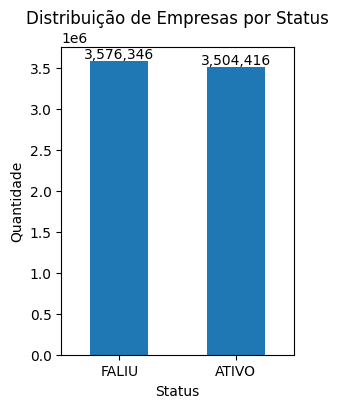

In [135]:
# Contagem
contagem = df_analise["status"].value_counts()

# Criar figura com tamanho
plt.figure(figsize=(3, 4))

# Plot
ax = contagem.plot(kind="bar")

# Títulos
plt.title("Distribuição de Empresas por Status")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)

# Adicionar rótulos nas barras
for i, v in enumerate(contagem):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.show()

#### **Qual é a taxa de "falência" por porte?**

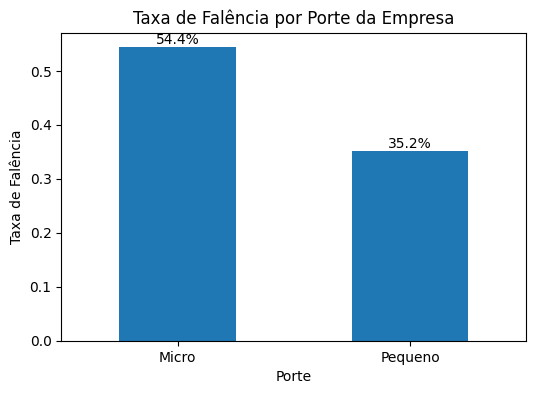

In [136]:
df_porte = (
    df_analise
    .groupby(["porte_da_empresa", "status"])
    .size()
    .unstack(fill_value=0)
)

# garantir colunas
df_porte = df_porte.reindex(columns=["ATIVO", "FALIU"], fill_value=0)

# taxa
df_porte["taxa_falencia"] = (
    df_porte["FALIU"] / (df_porte["FALIU"] + df_porte["ATIVO"])
)

df_plot = df_porte.sort_values(by="taxa_falencia", ascending=False)

plt.figure(figsize=(6, 4))

ax = df_plot["taxa_falencia"].plot(kind="bar")

plt.title("Taxa de Falência por Porte da Empresa")
plt.xlabel("Porte")
plt.ylabel("Taxa de Falência")
plt.xticks(rotation=0)

# rótulos
for i, v in enumerate(df_plot["taxa_falencia"]):
    ax.text(i, v, f"{v:.1%}", ha="center", va="bottom")

plt.show()

#### **Existe diferença por região (UF)?**

Verificando primeiro a taxa de falência para cada região.

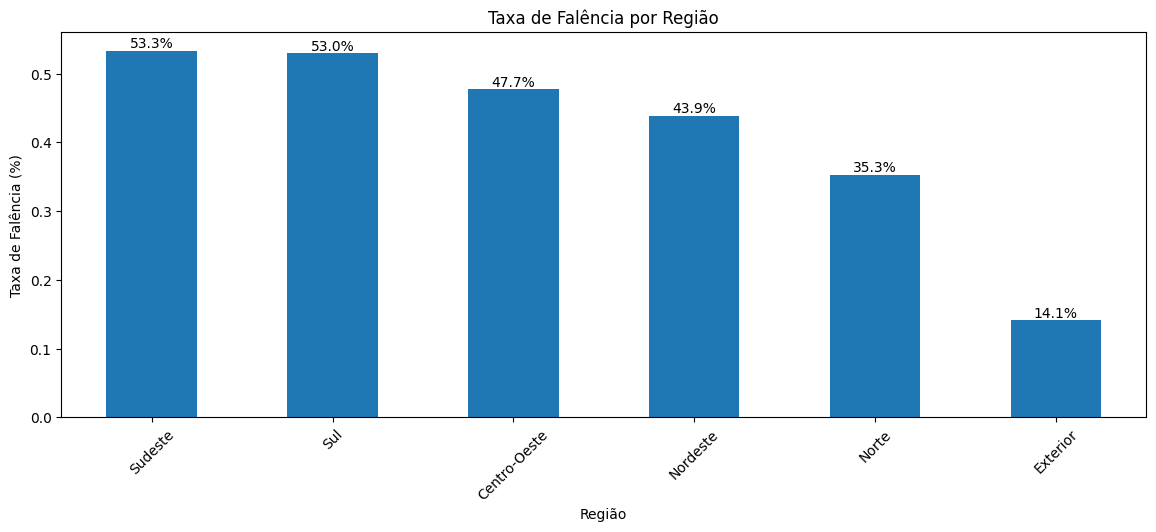

In [137]:
# Agrupamento
df_stack = (
    df_analise
    .groupby(["regiao", "status"])
    .size()
    .unstack(fill_value=0)
)

# Calcular taxa de falência
df_stack["taxa_falencia"] = df_stack["FALIU"] / df_stack.sum(axis=1)

# Ordenar do maior para o menor
df_stack = df_stack.sort_values(by="taxa_falencia", ascending=False)

# Plot
ax = df_stack["taxa_falencia"].plot(
    kind="bar",
    figsize=(14, 5)
)

plt.title("Taxa de Falência por Região")
plt.xlabel("Região")
plt.ylabel("Taxa de Falência (%)")
plt.xticks(rotation=45)

# Rótulos percentuais
for i, v in enumerate(df_stack["taxa_falencia"]):
    ax.text(
        i,
        v,
        f"{v:.1%}",
        ha="center",
        va="bottom"
    )

plt.show()

Verificanod a taxa de falência para cada estado UF.

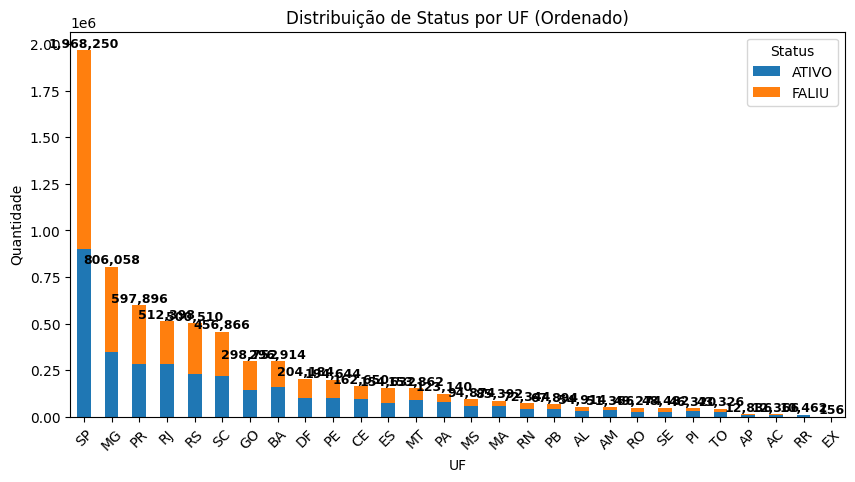

In [138]:
# Agrupamento
df_stack = (
    df_analise
    .groupby(["uf", "status"])
    .size()
    .unstack(fill_value=0)
)

# Total
df_stack["total"] = df_stack.sum(axis=1)

# Ordenar
df_stack = df_stack.sort_values(by="total", ascending=False)

# Plot
ax = df_stack.drop(columns="total").plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Distribuição de Status por UF (Ordenado)")
plt.xlabel("UF")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)

# Rótulo TOTAL no topo da barra
for i, total in enumerate(df_stack["total"]):
    ax.text(
        i,
        total,
        f"{int(total):,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.legend(title="Status")
plt.show()

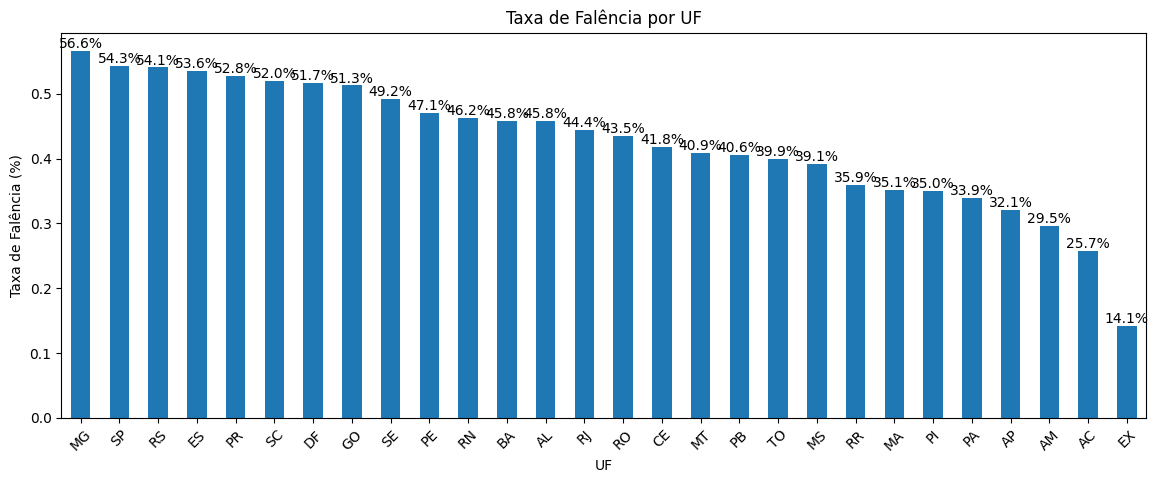

In [139]:
# Agrupamento
df_stack = (
    df_analise
    .groupby(["uf", "status"])
    .size()
    .unstack(fill_value=0)
)

# Calcular taxa de falência
df_stack["taxa_falencia"] = df_stack["FALIU"] / df_stack.sum(axis=1)

# Ordenar do maior para o menor
df_stack = df_stack.sort_values(by="taxa_falencia", ascending=False)

# Plot
ax = df_stack["taxa_falencia"].plot(
    kind="bar",
    figsize=(14, 5)
)

plt.title("Taxa de Falência por UF")
plt.xlabel("UF")
plt.ylabel("Taxa de Falência (%)")
plt.xticks(rotation=45)

# Rótulos percentuais
for i, v in enumerate(df_stack["taxa_falencia"]):
    ax.text(
        i,
        v,
        f"{v:.1%}",
        ha="center",
        va="bottom"
    )

plt.show()

#### **Empresas mais jovens falem mais?**

Sim, empresas mais jovens tendem a ter a maior possibilidade de falência, tendo em média 54% de chance para empresas de 3 a 10 de funcionamento.

C:\Users\leona\AppData\Local\Temp\ipykernel_16904\2994528086.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["faixa_idade", "status"])


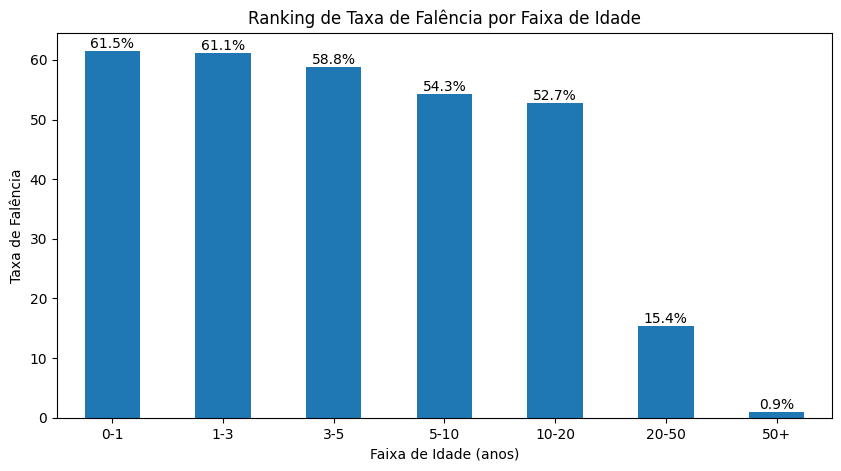

In [140]:
# Criando uma faixa de idade para as empresas
bins = [0, 1, 3, 5, 10, 20, 50, 100]
labels = ["0-1", "1-3", "3-5", "5-10", "10-20", "20-50", "50+"]

df_analise["faixa_idade"] = pd.cut(df_analise["tempo_funcionamento"], bins=bins, labels=labels)

df_idade = (
    df_analise
    .groupby(["faixa_idade", "status"])
    .size()
    .unstack(fill_value=0)
)

df_idade["taxa_falencia"] = (
    round(df_idade["FALIU"] / (df_idade["FALIU"] + df_idade["ATIVO"]) * 100, 2)
)

df_plot = df_idade.sort_values(by="taxa_falencia", ascending=False)

# Plot
ax = df_plot["taxa_falencia"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ranking de Taxa de Falência por Faixa de Idade")
plt.xlabel("Faixa de Idade (anos)")
plt.ylabel("Taxa de Falência")
plt.xticks(rotation=0)

# Rótulos percentuais
for i, v in enumerate(df_plot["taxa_falencia"]):
    ax.text(
        i,
        v,
        f"{v:.1f}%",
        ha="center",
        va="bottom"
    )
plt.show()

#### **Capital social influencia a sobrevivência?**

In [141]:
df_capital = (
    df_analise
    .groupby(["faixa_capital", "status"])
    .size()
    .unstack(fill_value=0)
)

df_capital = df_capital.reindex(columns=["ATIVO", "FALIU"], fill_value=0)

df_capital["taxa_falencia"] = df_capital["FALIU"] / (df_capital["FALIU"] + df_capital["ATIVO"])

C:\Users\leona\AppData\Local\Temp\ipykernel_16904\994745000.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["faixa_capital", "status"])


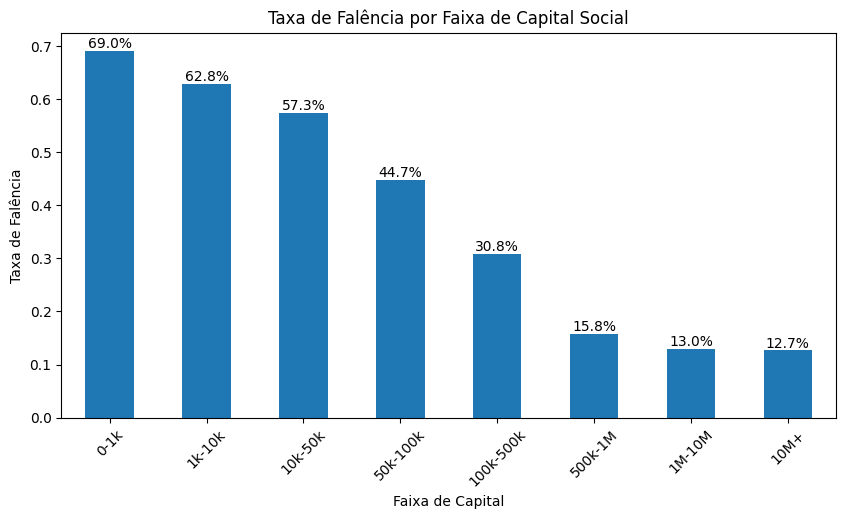

In [142]:
df_plot = df_capital.sort_values(by="taxa_falencia", ascending=False)

ax = df_plot["taxa_falencia"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Taxa de Falência por Faixa de Capital Social")
plt.xlabel("Faixa de Capital")
plt.ylabel("Taxa de Falência")
plt.xticks(rotation=45)

for i, v in enumerate(df_plot["taxa_falencia"]):
    ax.text(i, v, f"{v:.1%}", ha="center", va="bottom")

plt.show()

Quanto menor o capital social, maior a quantidade de empresas que faliram.

In [143]:
df_cross = (
    df_analise
    .groupby(["faixa_idade", "faixa_capital", "status"])
    .size()
    .unstack(fill_value=0)
)

df_cross["taxa_falencia"] = (
    round((df_cross["FALIU"] / (df_cross["FALIU"] + df_cross["ATIVO"]))* 100, 2)
)

df_cross = df_cross.reset_index()

# selecionar colunas
df_cross = df_cross[["faixa_idade", "faixa_capital", "taxa_falencia"]]

C:\Users\leona\AppData\Local\Temp\ipykernel_16904\187238797.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["faixa_idade", "faixa_capital", "status"])


Vamos analisar o mapa de calor entre faixa de idade e faixa de capital.

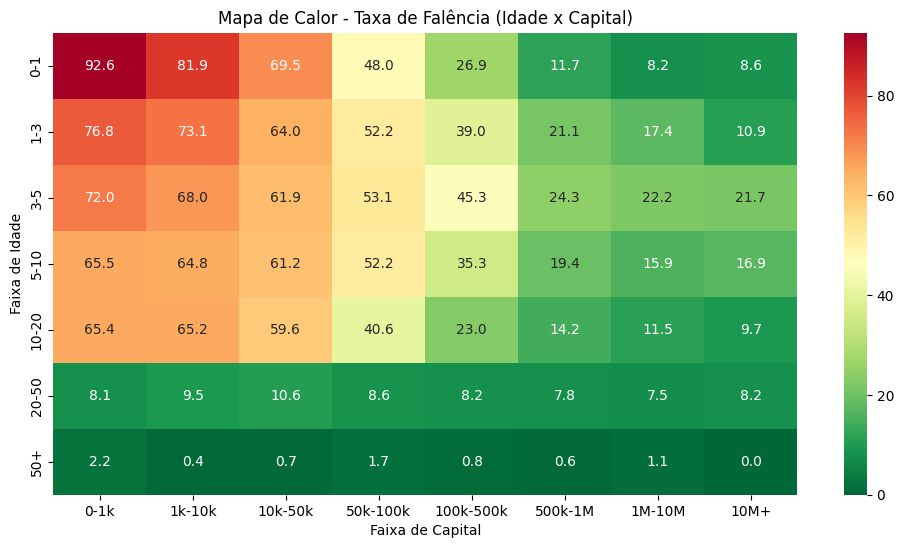

In [144]:
df_heatmap = df_cross.pivot(
    index="faixa_idade",
    columns="faixa_capital",
    values="taxa_falencia"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    df_heatmap,
    annot=True,          # mostra valores
    fmt=".1f",           # formato (percentual sem %)
    cmap="RdYlGn_r",     # vermelho = ruim, verde = bom
)

plt.title("Mapa de Calor - Taxa de Falência (Idade x Capital)")
plt.xlabel("Faixa de Capital")
plt.ylabel("Faixa de Idade")

plt.show()

Para empresas recém criadas até 20 anos de existência, a marca de 100k de capital determina uma diminuição significativa na probabilidade de falência. Quanto mais jovem e menor o capital social da empresa maior a probabiolidade dela falir, sendo o primeiro ano primordial para a continuidade da empresa.

### 2.3 Analisando influência da faixa etária e de capital a rgião específica

Para essa análise veremos apenas as regiões Sudeste, Nordeste e Norte, para verificar as influências para a região com a maior taxa e para as regiões com menor taxa.

#### 2.3.1 Sudeste

C:\Users\leona\AppData\Local\Temp\ipykernel_16904\4243553966.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["faixa_idade", "faixa_capital", "status"])


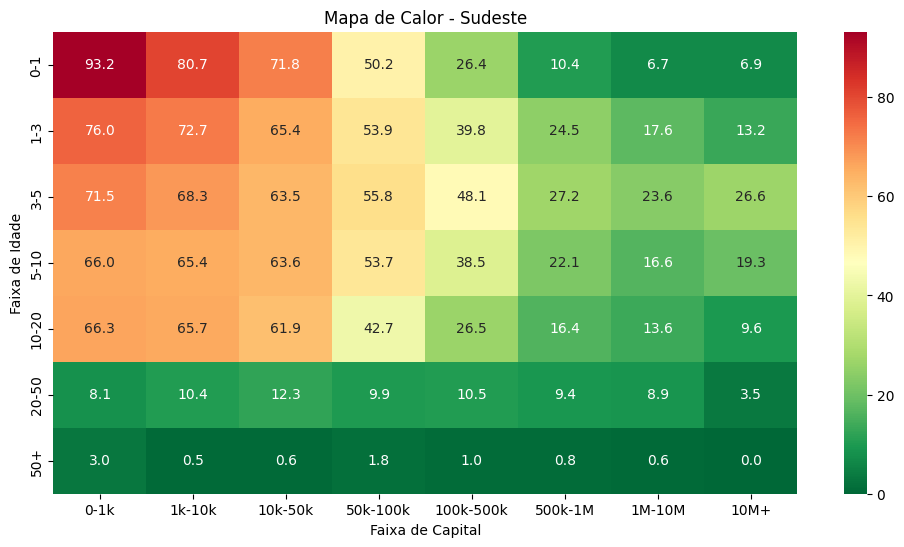

In [145]:
df_analise2 = df_analise[df_analise['regiao'] == 'Sudeste'].copy()

df_cross = (
    df_analise2
    .groupby(["faixa_idade", "faixa_capital", "status"])
    .size()
    .unstack(fill_value=0)
)

df_cross["taxa_falencia"] = (
    round((df_cross["FALIU"] / (df_cross["FALIU"] + df_cross["ATIVO"]))* 100, 2)
)

df_cross = df_cross.reset_index()

# selecionar colunas
df_cross = df_cross[["faixa_idade", "faixa_capital", "taxa_falencia"]]

df_heatmap = df_cross.pivot(
    index="faixa_idade",
    columns="faixa_capital",
    values="taxa_falencia"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    df_heatmap,
    annot=True,          # mostra valores
    fmt=".1f",           # formato (percentual sem %)
    cmap="RdYlGn_r",     # vermelho = ruim, verde = bom
)

plt.title("Mapa de Calor - Sudeste")
plt.xlabel("Faixa de Capital")
plt.ylabel("Faixa de Idade")

plt.show()

#### 2.3.2 Nordeste

C:\Users\leona\AppData\Local\Temp\ipykernel_16904\3670770029.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["faixa_idade", "faixa_capital", "status"])


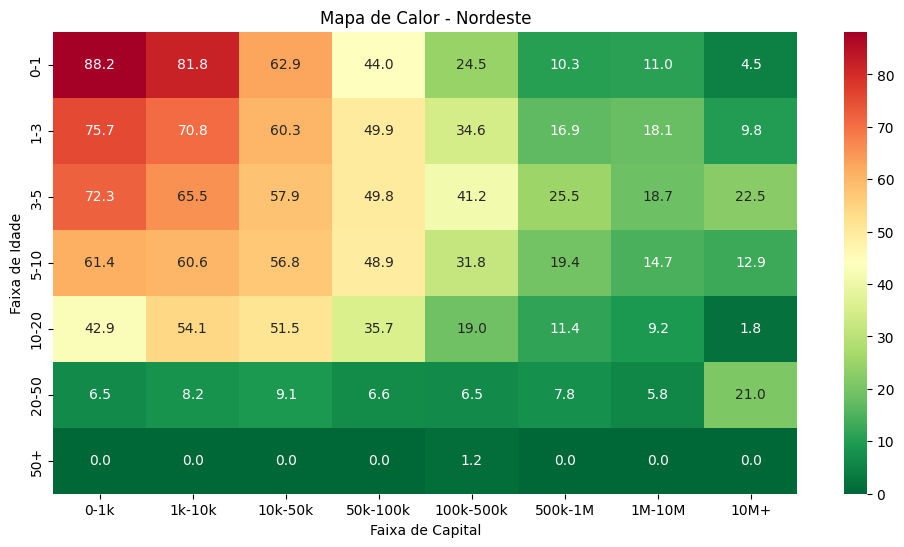

In [146]:
df_analise2 = df_analise[df_analise['regiao'] == 'Nordeste'].copy()

df_cross = (
    df_analise2
    .groupby(["faixa_idade", "faixa_capital", "status"])
    .size()
    .unstack(fill_value=0)
)

df_cross["taxa_falencia"] = (
    round((df_cross["FALIU"] / (df_cross["FALIU"] + df_cross["ATIVO"]))* 100, 2)
)

df_cross = df_cross.reset_index()

# selecionar colunas
df_cross = df_cross[["faixa_idade", "faixa_capital", "taxa_falencia"]]

df_heatmap = df_cross.pivot(
    index="faixa_idade",
    columns="faixa_capital",
    values="taxa_falencia"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    df_heatmap,
    annot=True,          # mostra valores
    fmt=".1f",           # formato (percentual sem %)
    cmap="RdYlGn_r",     # vermelho = ruim, verde = bom
)

plt.title("Mapa de Calor - Nordeste")
plt.xlabel("Faixa de Capital")
plt.ylabel("Faixa de Idade")

plt.show()

#### 2.3.3 Norte

C:\Users\leona\AppData\Local\Temp\ipykernel_16904\901422296.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["faixa_idade", "faixa_capital", "status"])


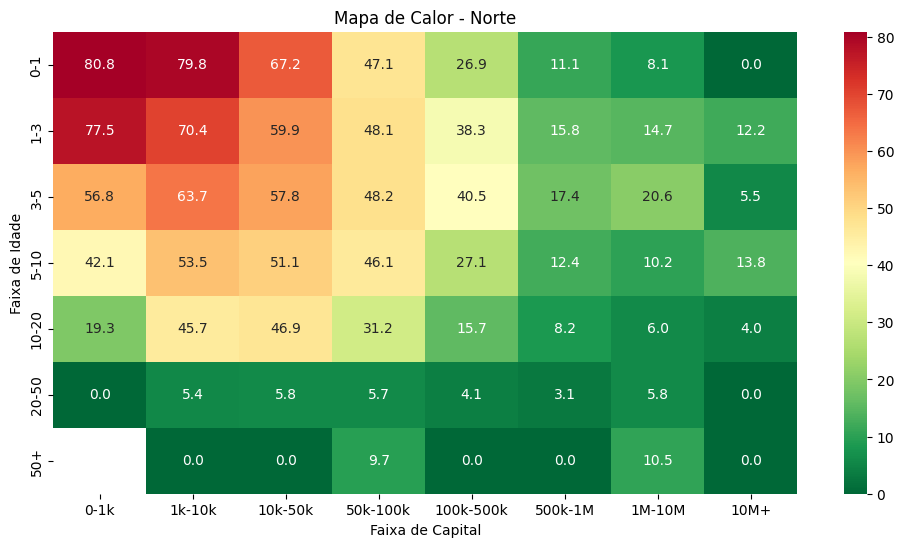

In [147]:
df_analise2 = df_analise[df_analise['regiao'] == 'Norte'].copy()

df_cross = (
    df_analise2
    .groupby(["faixa_idade", "faixa_capital", "status"])
    .size()
    .unstack(fill_value=0)
)

df_cross["taxa_falencia"] = (
    round((df_cross["FALIU"] / (df_cross["FALIU"] + df_cross["ATIVO"]))* 100, 2)
)

df_cross = df_cross.reset_index()

# selecionar colunas
df_cross = df_cross[["faixa_idade", "faixa_capital", "taxa_falencia"]]

df_heatmap = df_cross.pivot(
    index="faixa_idade",
    columns="faixa_capital",
    values="taxa_falencia"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    df_heatmap,
    annot=True,          # mostra valores
    fmt=".1f",           # formato (percentual sem %)
    cmap="RdYlGn_r",     # vermelho = ruim, verde = bom
)

plt.title("Mapa de Calor - Norte")
plt.xlabel("Faixa de Capital")
plt.ylabel("Faixa de Idade")

plt.show()

Para a análise por regiões obtemos os seguintes insghts:

- Vemos aqui a manutenção da regra geral descoberta anteriormente, o primeiro ano é um marco essêncial para a continuidade da empresa, tal perspectiva só é quebrada de acordo com o capital;
- Quanto mais antiga a empresa menores os riscos de falência;
- Para a região sudeste temos uma maior estabilidade após as marcas de 10 anos e capital superior a 100k em comparação a outras regiões, no entanto o risco ao iniciar o negócio é muito maior, tal comportamento nos revela um ambiante mais propício para empresas de tradição e maior capital;
- Para a região nordeste vemos muita variabilidade demonstrando que o capital auxilia mas não é um definidor, para empresas de 3-5 anos temos as taxas de falência mais perigosas denotando um momento perigoso no crescimento da empresa;
- Para a região norte vemos um comportamento parecido a região nordeste, no entanto, a faixa etária das empresas diminuiu determinando um novo marco para melhora de possibilidade de continuidade da empresa, ou seja, menor tempo para aumentar as chances de continuidade da empresa.

### 2.4 Analisando influência da situação jurídica

Neste marco analisaremos essa influência para as empresas de até 5 anos de existência por ser o alvo deste estudo.

In [148]:
df_ate_5 = df_analise[df_analise["tempo_funcionamento"] <= 5].copy()

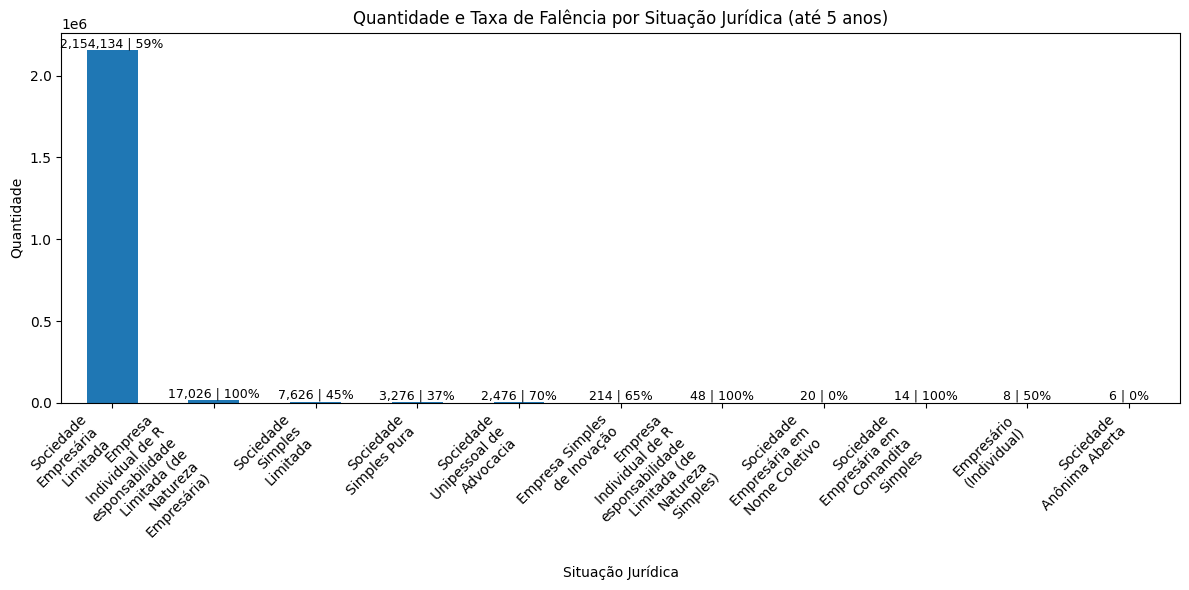

In [149]:
df_plot = (
    df_ate_5
    .groupby(["sit_juridica", "status"])
    .size()
    .unstack(fill_value=0)
)

# garantir colunas
df_plot = df_plot.reindex(columns=["ATIVO", "FALIU"], fill_value=0)

# métricas
df_plot["total"] = df_plot["ATIVO"] + df_plot["FALIU"]
df_plot["taxa_falencia"] = df_plot["FALIU"] / df_plot["total"]

# ordenar
df_plot = df_plot.sort_values(by="total", ascending=False)

# 🔹 AQUI sim aplica a quebra
df_plot.index = df_plot.index.map(lambda x: quebrar_texto(x, 15))

# plot
plt.figure(figsize=(12, 6))

ax = df_plot["total"].plot(kind="bar")

plt.title("Quantidade e Taxa de Falência por Situação Jurídica (até 5 anos)")
plt.xlabel("Situação Jurídica")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")

# rótulos
for i, (total, taxa) in enumerate(zip(df_plot["total"], df_plot["taxa_falencia"])):
    label = f"{int(total):,} | {taxa:.0%}"
    
    ax.text(
        i,
        total,
        label,
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

Considerando o volume acima de 2.000 como significativo vemo uma das naturezas juridicas dá certeza de falência que seria *Empresa Individual de Responsabilidade Limitada*.

Outras naturezas juridicas são indicadores de aumento de probabilidade de falência. Seriam eles:
- Sociedade Unipessoal de Advocacia
- Sociedade Empresária Limitada

E existem algumas naturezas juridicas que diminuem a probabilidade de falência em até 5 anos:
- Sociedade Simples Pura
- Sociedade Simples Limitada

### 2.5 Analisando influência da dos tempos tempo_op_simples, tempo_excl_op_simples e tempo_exclusao_mei

Vamos analisar este tópico na perspectiva das empresas que não faliram dentro de 5 anos para verificar algum comportamento positivo.

In [150]:
df_ate_5_status = df_analise[(df_analise["tempo_funcionamento"] <= 5) & (df_analise['status'] == 'ATIVO')].copy()

- Faixa de Capital

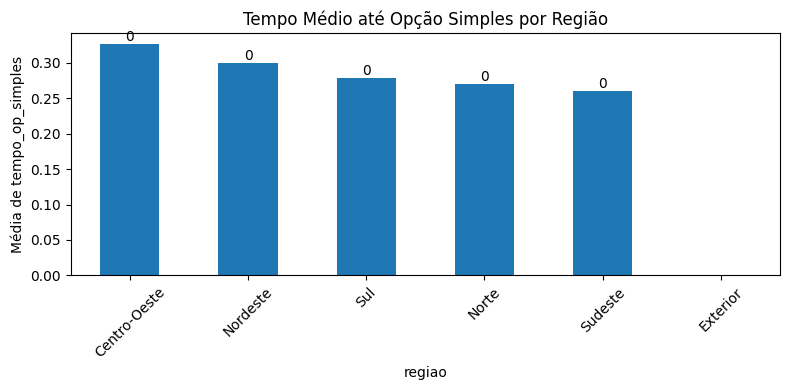

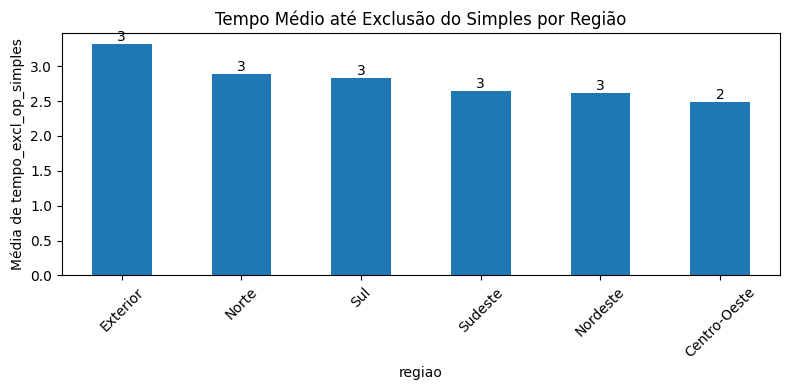

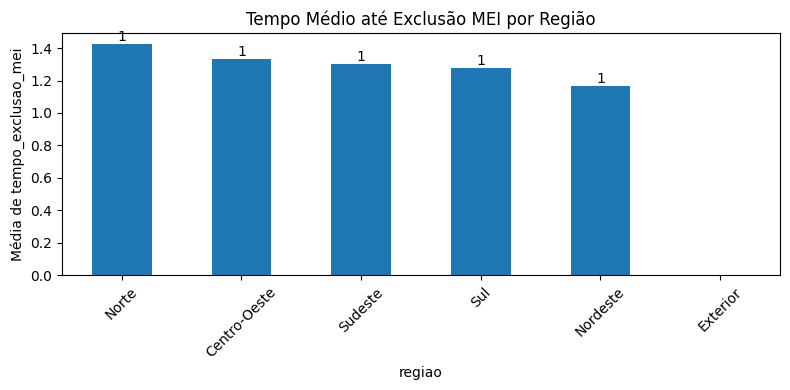

In [151]:
plot_media(
    df_ate_5_status,
    "tempo_op_simples",
    "regiao",
    "Tempo Médio até Opção Simples por Região"
)

plot_media(
    df_ate_5_status,
    "tempo_excl_op_simples",
    "regiao",
    "Tempo Médio até Exclusão do Simples por Região"
)

plot_media(
    df_ate_5_status,
    "tempo_exclusao_mei",
    "regiao",
    "Tempo Médio até Exclusão MEI por Região"
)

- Região

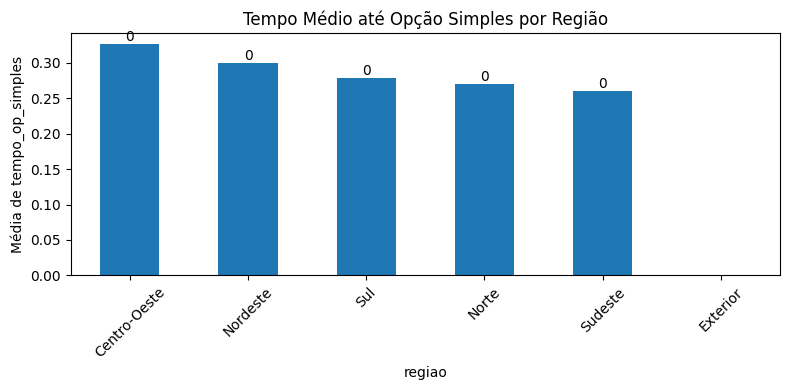

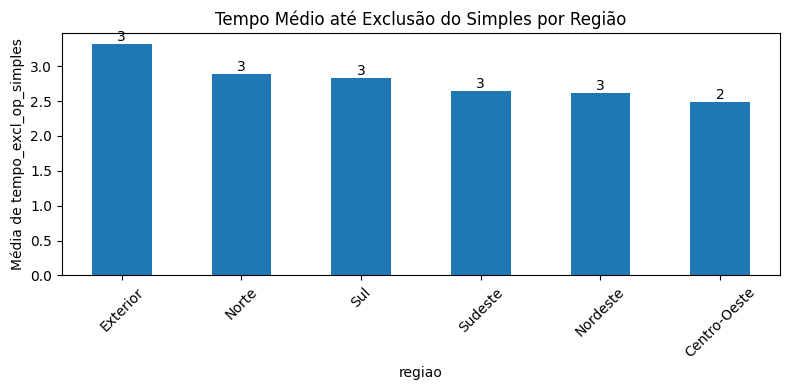

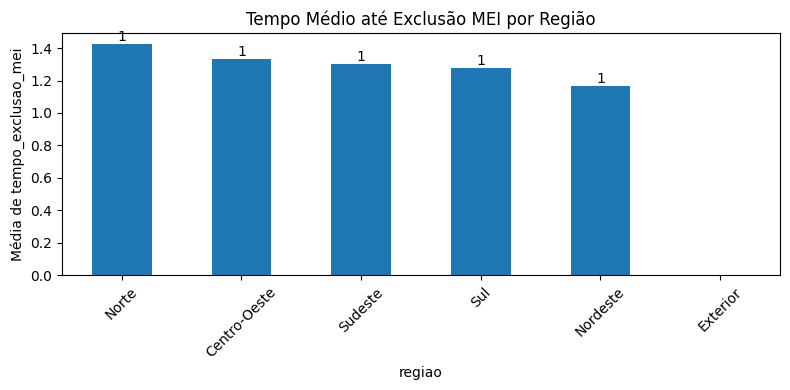

In [152]:
plot_media(
    df_ate_5_status,
    "tempo_op_simples",
    "regiao",
    "Tempo Médio até Opção Simples por Região"
)

plot_media(
    df_ate_5_status,
    "tempo_excl_op_simples",
    "regiao",
    "Tempo Médio até Exclusão do Simples por Região"
)

plot_media(
    df_ate_5_status,
    "tempo_exclusao_mei",
    "regiao",
    "Tempo Médio até Exclusão MEI por Região"
)

## 3. Conclusões

Durante a exploração de dados vimos que a taxa de falência foi 51% nos indicando que mais da metade das empresas registradas faliram no mês analisado, sendo que 54% das empresas que faliram eram micro-empresas, ou seja, menor capital e provavelmente empresas em início de trajetória.

Ao analisarmos a distribuição de empresas que faliram por estado, vimos uma concentração de resultados negativos em determiandas regiões indicando influência da localidade nos resultados.

Dessa forma foi traçado as seguintes premissas:

### Premissa 1. O Ano 1 é o marco mais importante para a continuidade do negócio

A taxa de falência para as regiões varia aproximadamente de 88% ~ 90% cainda vertiginosamente após esse ano para em média de 60%. Tendo em vista o tamanho do capital as chances de passar do primeiro ano melhoram, mas apenas se for superior a 100k.

### Premissa 2. A taxa de falência cai de acordo com a faixa etária da empresa a partir de 20 anos

O tempo em que a empresa está aberta se torna significativo quando ultrapassa o marco dos 20 anos, até lá 50% das empresas falem em média. Para empresas de até 5 anos o percentual chega a ~58%

### Premissa 3. Região aliado a faixa etária e capital podem determinar a continuidade da empresa

- Sudeste e Sul: Chance de falência de 90% no primeiro ano para micro-empresas sendo São Paulo o estado com melhores possibilidades, sendo necessário alcançar um capital e pelo menos 100K até o 5 ano para definir uma probabilidade mairo de continuidade.

- Norte e Nordeste: Chance de falência de 80% no primeiro ano para micro-empresas, sendo necessário alcançar um capital e pelo menos 500k até o 5 ano para definir uma probabilidade mairo de continuidade.

### Premissa 4. Natureza jurídica

- Ter a natureza jurídica classificadas como Sociedade Simples Limitada, Sociedade Simples Pura ou Sociedade Empresária Limitada para aumetar a chance de não falir dentro de 5 anos.

### Premissa 5. Tempos relevantes

Para as empresas não falirem precisam ter: 
- Tempo como MEI de até 1 ano e 3 meses;
- E ser da categoria de Opção Simples de 2 a 3 anos;